# PARcast — E_s(PAR) surface reference figures (all samples)

The surface SQ-500 is a standalone above-water logger: incident PAR over time, with **no depth** and **no immersion correction** (it sits in air). Reads one surface file and writes figures to `<FIG_BASE>/E_sPAR/<shortname>_<datafile>.png`, also shown inline.

**Figures:** timeline, distribution, variability (variability = how steady the sky was, the assumption the single-instrument E_d K_d fit leans on).

**How to use:** set `ES_SURFACE_CSV` below, then Run All.




*** PACIFIC TIME ???****

### test files 

Pool (csv structure might be different look at v1 of jupyter notebook)
E_dzPAR_20260524 and 25 however ending nomenclature changes after 25 

Kramer's cove
E_dzPAR_20260604_0001.CSV

Kramer's cove
E_dzPAR_20260605_0003.CSV

NASA SARP cruise in the Texas Gulf 
E_dzPAR_20260608_0001.CSV;
E_sPAR_20260608_0001.CSV
* refere to field notes, there were casts where we lowered into 0.1-0.5m of water and pulled instument back on deck to change heading of vessel relative to swell and current.

## Config

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

ES_SURFACE_CSV = '/Users/loriberberian/Desktop/PARcast/data_processing/raw/E_sPAR/E_sPAR_20260608_0001.CSV'
FIG_BASE       = '/Users/loriberberian/Desktop/PARcast/data_processing/figures'

ES_SENSITIVITY = 100.0      # umol m-2 s-1 per mV (SQ-500); surface is in air -> NO immersion
VAR_WINDOW_S   = 30.0       # seconds; rolling-CV window for the sky-steadiness panel

STEM   = os.path.splitext(os.path.basename(ES_SURFACE_CSV))[0]   # e.g. E_sPAR_20260608_0001
OUTDIR = os.path.join(FIG_BASE, "E_sPAR")
os.makedirs(OUTDIR, exist_ok=True)

def savefig(fig, shortname):
    path = os.path.join(OUTDIR, f"{shortname}_{STEM}.png")
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print("saved", path)

print("figures will be written to:", OUTDIR)

figures will be written to: /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_sPAR


## Load (defensive)
The surface logger's column names may differ from the profiler's. This auto-detects the time column and the PAR-voltage column and prints what it found — check that line.

In [28]:
ES_SOURCE = "mv"   # "mv" -> Es = millivolts * ES_SENSITIVITY ; "ppfd" -> trust logger PPFD column

def load_surface(path):
    df = pd.read_csv(path)
    # time column: prefer known names, else first column that parses as datetime
    tcol = None
    for c in (["iso_time", "datetime", "time", "timestamp"] + list(df.columns)):
        if c in df.columns:
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() > 0.5:
                tcol = c; df[c] = parsed; break
    if tcol is None:
        raise ValueError(f"no datetime column found (columns: {list(df.columns)})")
    # PAR columns: a millivolt column and/or an already-converted PPFD column
    mv_names   = ["par_mV", "par_mv", "parmV", "millivolts", "mV", "mv"]
    ppfd_names = ["par_uMol_m2_s", "ppfd_umol_m2_s", "ppfd", "par_uMol", "umol_m2_s"]
    mv_col   = next((c for c in mv_names   if c in df.columns), None)
    ppfd_col = next((c for c in ppfd_names if c in df.columns), None)
    df = df.rename(columns={tcol: "iso_time"})
    df = df.dropna(subset=["iso_time"]).sort_values("iso_time").reset_index(drop=True)
    if ES_SOURCE == "ppfd":
        if ppfd_col is None:
            raise ValueError(f"ES_SOURCE='ppfd' but no PPFD column (columns: {list(df.columns)})")
        df["Es"] = df[ppfd_col].astype(float); par_used = ppfd_col
    else:
        if mv_col is None:
            raise ValueError(f"ES_SOURCE='mv' but no millivolt column (columns: {list(df.columns)})")
        df["par_mV"] = df[mv_col].astype(float)
        df["Es"] = df["par_mV"] * ES_SENSITIVITY; par_used = mv_col
    n0 = len(df)
    df = df[df["Es"].notna() & (df["Es"] >= 0)].reset_index(drop=True)
    df.attrs["bad_rows_dropped"]  = n0 - len(df)
    df.attrs["time_col_detected"] = tcol
    df.attrs["par_col_detected"]  = f"{par_used} (ES_SOURCE={ES_SOURCE})"
    return df

surf = load_surface(ES_SURFACE_CSV)
print(f"detected time column '{surf.attrs['time_col_detected']}', PAR column '{surf.attrs['par_col_detected']}'")
print(f"{len(surf)} rows, {surf.attrs.get('bad_rows_dropped', 0)} bad rows dropped")
print(f"Es {surf.Es.min():.0f}-{surf.Es.max():.0f} umol m-2 s-1, median {surf.Es.median():.0f}")
surf.head(3)

detected time column 'datetime', PAR column 'millivolts (ES_SOURCE=mv)'
10126 rows, 0 bad rows dropped
Es 0-1948 umol m-2 s-1, median 573


,iso_time,raw_counts,millivolts,ppfd_umol_m2_s,par_mV,Es
0,2026-06-08 06:43:24,1,0.0078,0.78,0.0078,0.78
1,2026-06-08 06:43:25,1,0.0078,0.78,0.0078,0.78
2,2026-06-08 06:43:26,0,0.0000,0.00,0.0000,0.00


## Figure: timeline
Incident surface PAR over the whole deployment, every sample.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_sPAR/timeline_E_sPAR_20260608_0001.png


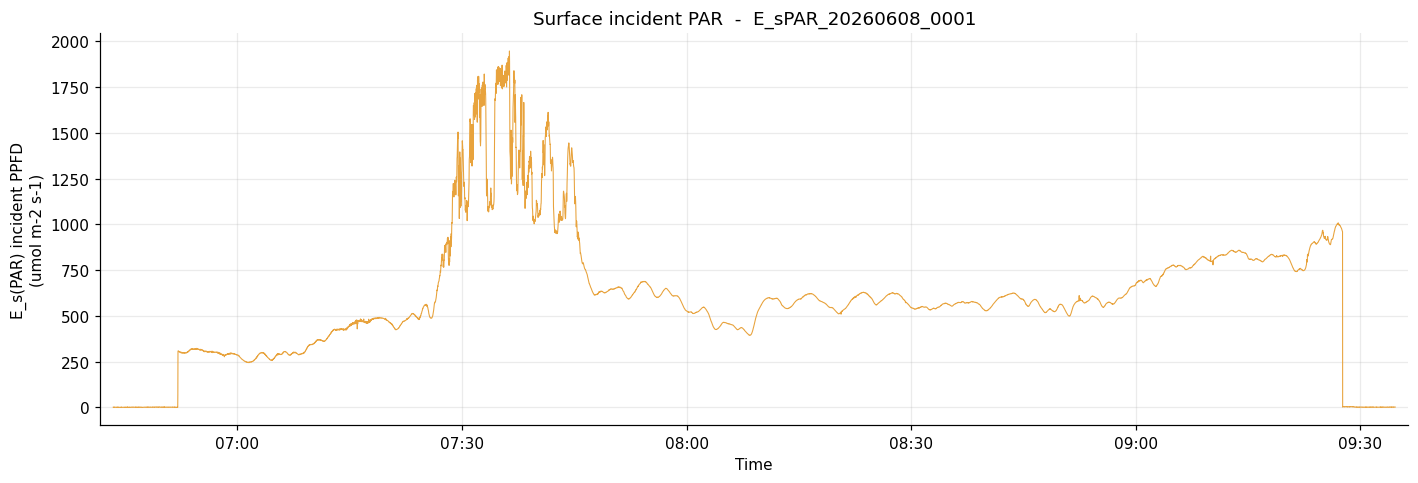

In [29]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(surf.iso_time, surf.Es, color="#e8a33d", lw=0.7)
ax.set_ylabel("E_s(PAR) incident PPFD\n(umol m-2 s-1)"); ax.set_xlabel("Time")
ax.set_title(f"Surface incident PAR  -  {STEM}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.margins(x=0.01)
fig.tight_layout(); savefig(fig, "timeline"); plt.show()

## Figure: distribution
Histogram of all incident-PAR samples.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_sPAR/distribution_E_sPAR_20260608_0001.png


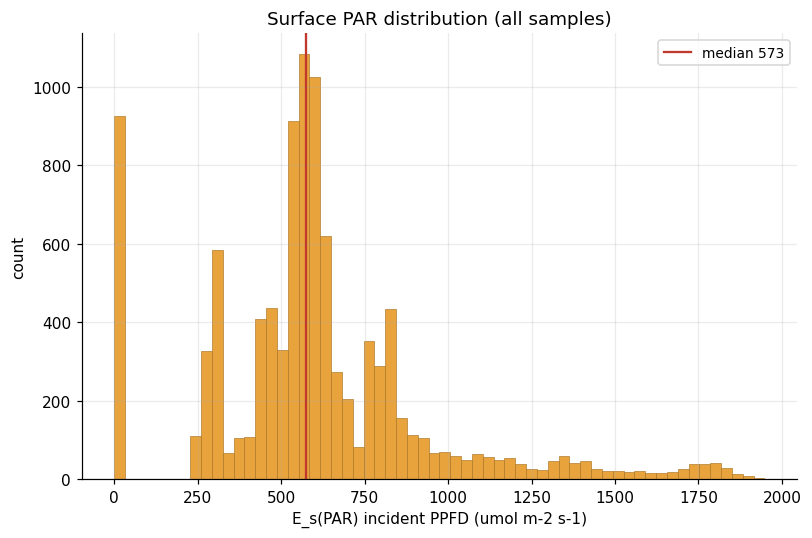

In [30]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.hist(surf.Es, bins=60, color="#e8a33d", edgecolor="#a8721f", linewidth=0.4)
ax.axvline(surf.Es.median(), color="#c0392b", lw=1.5, label=f"median {surf.Es.median():.0f}")
ax.set_xlabel("E_s(PAR) incident PPFD (umol m-2 s-1)"); ax.set_ylabel("count")
ax.set_title("Surface PAR distribution (all samples)")
ax.legend(fontsize=9)
fig.tight_layout(); savefig(fig, "distribution"); plt.show()

## Figure: variability
Rolling coefficient of variation = how steady the sky was. Low CV during your cast windows means the single-instrument E_d K_d assumption (steady incident light) holds well.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_sPAR/variability_E_sPAR_20260608_0001.png


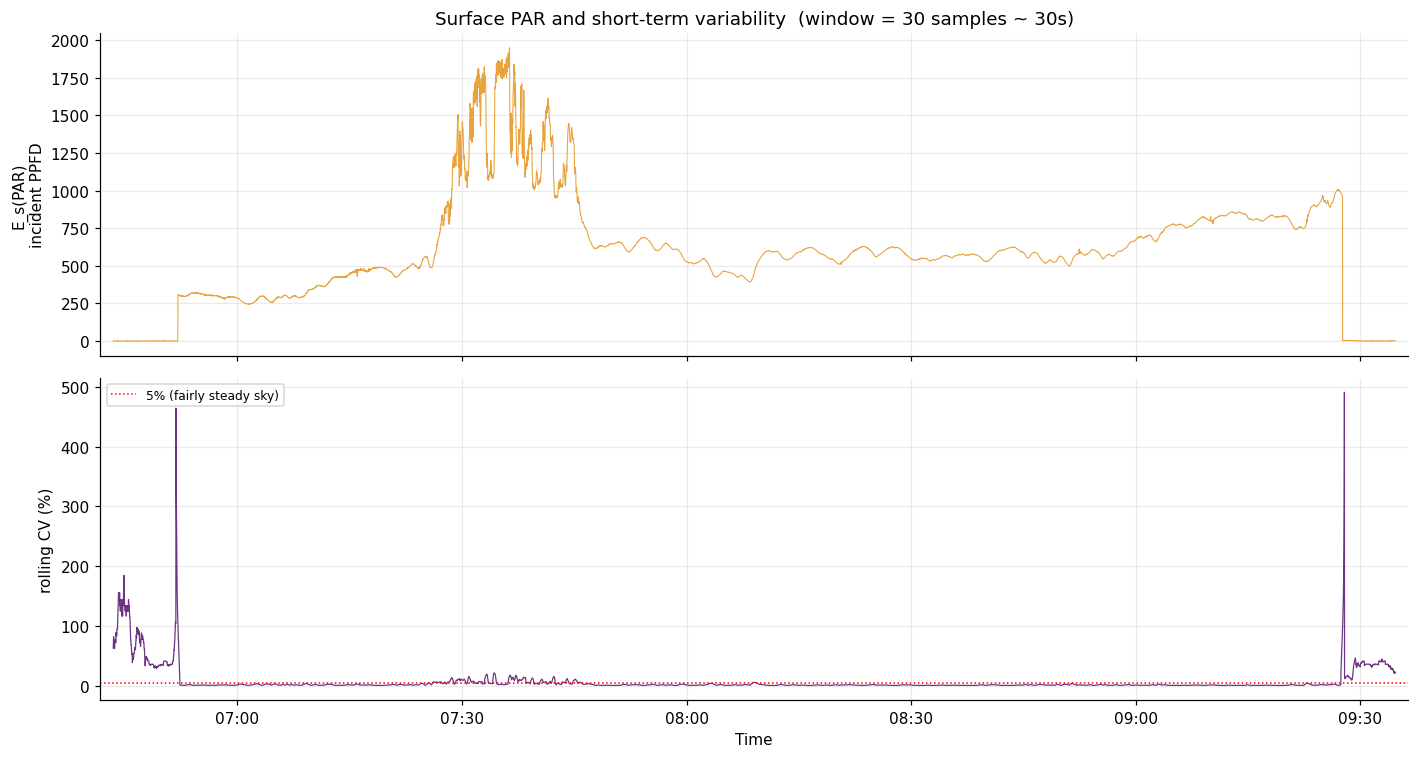

median short-term CV = 1.1%  (low = steady sky)


In [31]:
dt_s = surf.iso_time.diff().dt.total_seconds().median()
win = max(3, int(round(VAR_WINDOW_S / dt_s))) if dt_s and dt_s > 0 else 30
roll = surf.Es.rolling(win, center=True, min_periods=max(3, win // 3))
cv = 100.0 * roll.std() / roll.mean()

fig, (axT, axB) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axT.plot(surf.iso_time, surf.Es, color="#e8a33d", lw=0.7)
axT.set_ylabel("E_s(PAR)\nincident PPFD")
axT.set_title(f"Surface PAR and short-term variability  (window = {win} samples ~ {VAR_WINDOW_S:.0f}s)")
axB.plot(surf.iso_time, cv, color="#6c3483", lw=0.8)
axB.set_ylabel("rolling CV (%)"); axB.set_xlabel("Time")
axB.axhline(5, color="red", ls=":", lw=1, label="5% (fairly steady sky)")
axB.legend(fontsize=8)
axB.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
for a in (axT, axB): a.margins(x=0.01)
fig.tight_layout(); savefig(fig, "variability"); plt.show()

print(f"median short-term CV = {np.nanmedian(cv):.1f}%  (low = steady sky)")